# Predicting Genre-Based Artist Breakout Potential Using Spotify Audio Features

**DS 4400 Final Project**  
**Team Members:** Aditya Anantharaman, Teja Kalapatapu

## 1. Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load and Combine Data

In [4]:
high_df = pd.read_csv("high_popularity_spotify_data.csv")
low_df = pd.read_csv("low_popularity_spotify_data.csv")

high_df["source_dataset"] = "high"
low_df["source_dataset"] = "low"

df = pd.concat([high_df, low_df], ignore_index=True)

print("Shape before cleaning:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape before cleaning: (4831, 30)

Columns:
['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness', 'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness', 'track_popularity', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'instrumentalness', 'track_album_id', 'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre', 'type', 'playlist_id', 'source_dataset']


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_href,uri,track_album_name,playlist_name,analysis_url,track_id,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,source_dataset
0,0.5920,157.9690,0.5210,pop,-7.7770,0.1220,0.5350,"Lady Gaga, Bruno Mars",3.0000,0.0304,100,https://api.spotify.com/v1/tracks/2plbrEY59Iik...,spotify:track:2plbrEY59IikOBgBGLjaoe,Die With A Smile,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/2plb...,2plbrEY59IikOBgBGLjaoe,Die With A Smile,2024-08-16,0.0000,10FLjwfpbxLmW8c25Xyc2N,0.0000,6.0000,251668.0000,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
1,0.5070,104.9780,0.7470,pop,-10.1710,0.1170,0.4380,Billie Eilish,4.0000,0.0358,97,https://api.spotify.com/v1/tracks/6dOtVTDdiauQ...,spotify:track:6dOtVTDdiauQNBQEDOtlAB,HIT ME HARD AND SOFT,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/6dOt...,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,2024-05-17,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1.0000,2.0000,210373.0000,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
2,0.8080,108.5480,0.5540,pop,-4.1690,0.1590,0.3720,Gracie Abrams,4.0000,0.0368,93,https://api.spotify.com/v1/tracks/7ne4VBA60CxG...,spotify:track:7ne4VBA60CxGM75vw0EYad,The Secret of Us (Deluxe),Today's Top Hits,https://api.spotify.com/v1/audio-analysis/7ne4...,7ne4VBA60CxGM75vw0EYad,That’s So True,2024-10-18,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1.0000,1.0000,166300.0000,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
3,0.9100,112.9660,0.6700,pop,-4.0700,0.3040,0.7860,Sabrina Carpenter,4.0000,0.0634,81,https://api.spotify.com/v1/tracks/1d7Ptw3qYcfp...,spotify:track:1d7Ptw3qYcfpdLNL5REhtJ,Short n' Sweet,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/1d7P...,1d7Ptw3qYcfpdLNL5REhtJ,Taste,2024-08-23,0.0000,4B4Elma4nNDUyl6D5PvQkj,0.0000,0.0000,157280.0000,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
4,0.7830,149.0270,0.7770,pop,-4.4770,0.3550,0.9390,"ROSÉ, Bruno Mars",4.0000,0.2600,98,https://api.spotify.com/v1/tracks/5vNRhkKd0yEA...,spotify:track:5vNRhkKd0yEAg8suGBpjeY,APT.,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/5vNR...,5vNRhkKd0yEAg8suGBpjeY,APT.,2024-10-18,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0.0000,0.0000,169917.0000,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high


## 3. Data Cleaning and Target Variable Construction

We drop duplicates, keep fields necessary for modelling, and create the target variable.

**Genre Percentile** is the percentile rank of a track's popularity **within its own genre**

In [5]:
required_cols = [
    "track_popularity",
    "playlist_genre",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "mode",
    "key"
]

df = df.drop_duplicates()
df = df.dropna(subset=required_cols).copy()

df["genre_percentile"] = (
    df.groupby("playlist_genre")["track_popularity"]
      .transform(lambda x: x.rank(pct=True))
)

features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "mode",
    "key"
]

target = "genre_percentile"

X = df[features].copy()
y = df[target].copy()

print("Shape after cleaning:", df.shape)
print("Number of records:", len(df))
print("Number of genres:", df["playlist_genre"].nunique())
print("Number of model features:", len(features))
print("\nMissing values in selected columns:")
print(df[required_cols + ["source_dataset", "genre_percentile"]].isnull().sum())

Shape after cleaning: (4830, 31)
Number of records: 4830
Number of genres: 35
Number of model features: 12

Missing values in selected columns:
track_popularity    0
playlist_genre      0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
mode                0
key                 0
source_dataset      0
genre_percentile    0
dtype: int64


## 4. Dataset Summary

In [6]:
summary_df = pd.DataFrame({
    "Statistic": [
        "Total records",
        "Number of features used",
        "Number of genres",
        "Missing values in selected features"
    ],
    "Value": [
        len(df),
        len(features),
        df["playlist_genre"].nunique(),
        int(df[required_cols].isnull().sum().sum())
    ]
})

summary_df

,Statistic,Value
0,Total records,4830
1,Number of features used,12
2,Number of genres,35
3,Missing values in selected features,0


In [7]:
genre_counts = df["playlist_genre"].value_counts().rename_axis("playlist_genre").reset_index(name="count")
genre_counts.head(10)

,playlist_genre,count
0,electronic,589
1,pop,515
2,latin,425
3,hip-hop,395
4,ambient,359
5,rock,345
6,lofi,298
7,world,228
8,arabic,208
9,brazilian,148


# 5. EDA
These plots are meant to support the following report narratives:
- raw popularity is skewed
- the normalized target is more balanced
- genres are imbalanced
- the source split creates structural bias
- many individual features have only weak relationships with the target

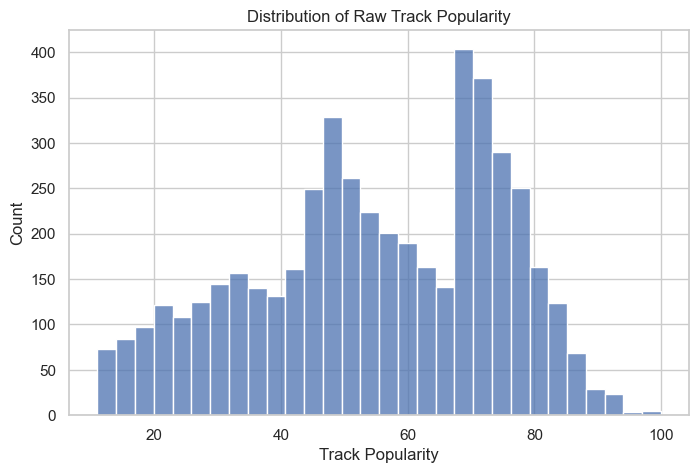

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["track_popularity"], bins=30)
plt.title("Distribution of Raw Track Popularity")
plt.xlabel("Track Popularity")
plt.ylabel("Count")
plt.show()

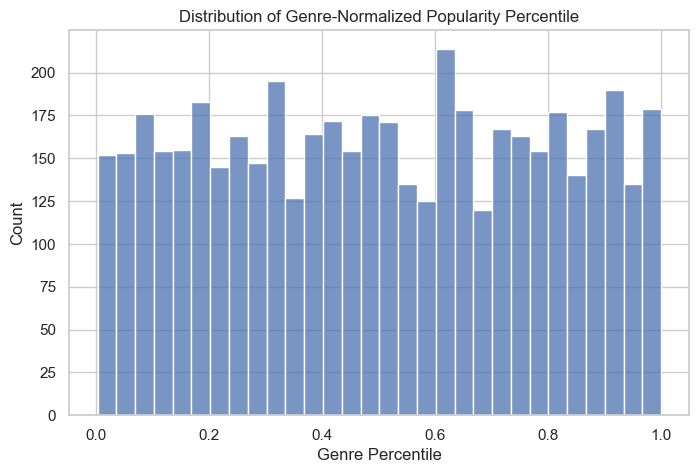

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["genre_percentile"], bins=30)
plt.title("Distribution of Genre-Normalized Popularity Percentile")
plt.xlabel("Genre Percentile")
plt.ylabel("Count")
plt.show()

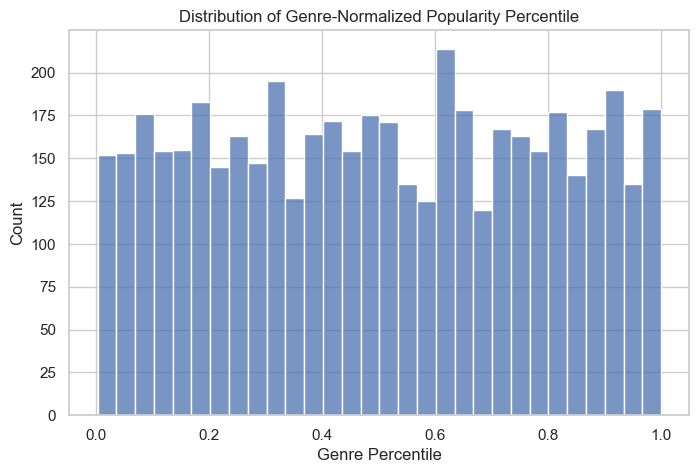

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["genre_percentile"], bins=30)
plt.title("Distribution of Genre-Normalized Popularity Percentile")
plt.xlabel("Genre Percentile")
plt.ylabel("Count")
plt.show()

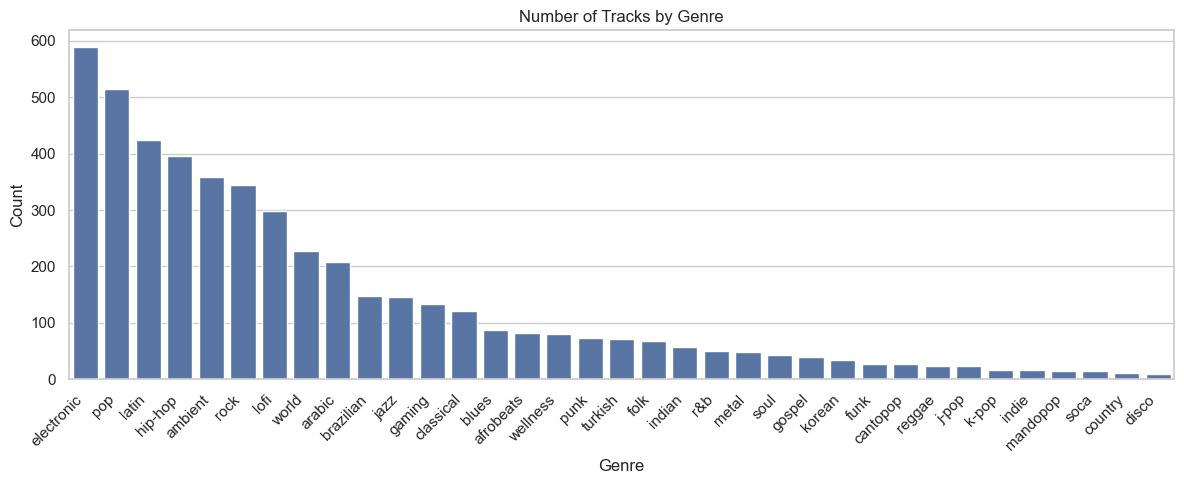

In [11]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="playlist_genre", order=df["playlist_genre"].value_counts().index)
plt.title("Number of Tracks by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

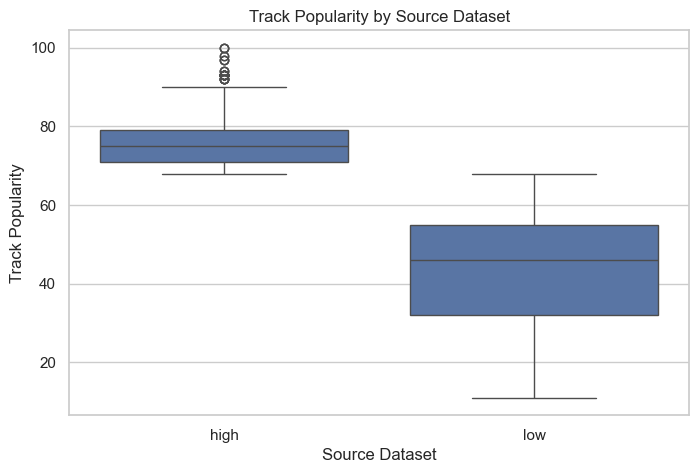

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="source_dataset", y="track_popularity")
plt.title("Track Popularity by Source Dataset")
plt.xlabel("Source Dataset")
plt.ylabel("Track Popularity")
plt.show()

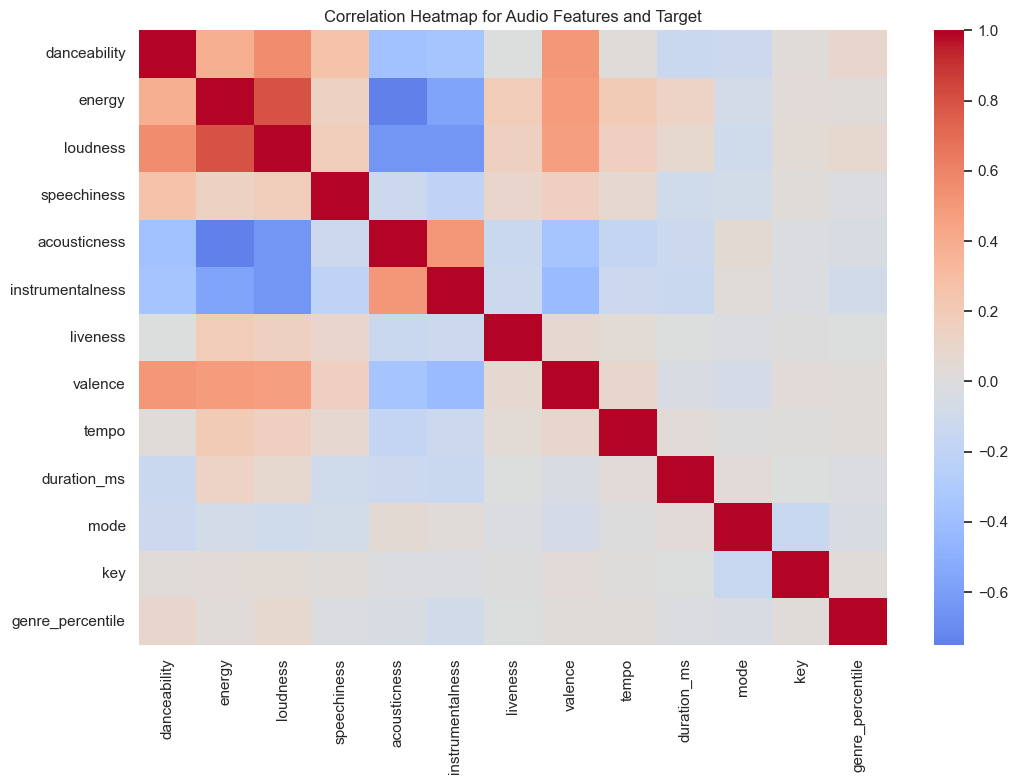

In [13]:
corr = df[features + ["genre_percentile"]].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Audio Features and Target")
plt.tight_layout()
plt.show()

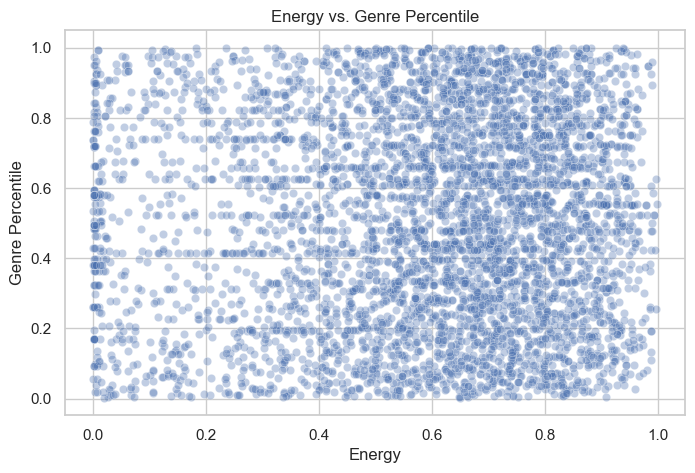

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="energy", y="genre_percentile", alpha=0.35)
plt.title("Energy vs. Genre Percentile")
plt.xlabel("Energy")
plt.ylabel("Genre Percentile")
plt.show()

## 6. Train / Test Split

In [15]:
X_train, X_test, y_train, y_test, train_genres, test_genres = train_test_split(
    X,
    y,
    df["playlist_genre"],
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3622, 12)
Test shape: (1208, 12)


## 7. Helper Functions

We evaluate models using:
- RMSE
- MAE
- R^2
- Spearman Rank Correlation

Spearman is useful here because ranking relative outperformers is more important than predicting the exact percentile perfectly.

In [16]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        "Model": model_name,
        "RMSE": rmse(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds),
        "Spearman": spearmanr(y_test, preds).correlation,
        "Predictions": preds
    }

def spearman_scorer_func(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation

spearman_scorer = make_scorer(spearman_scorer_func)

## 8. Model Training

We compare a mix of linear, regularized linear, and nonlinear ensemeble models. Lasso is included in the final version mainly to test whether feature sparsity helps at all after seeing weak baseline linear performance.

In [17]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        objective="reg:squarederror"
    )
}

In [18]:
results = []
predictions = {}

for name, model in models.items():
    result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    predictions[name] = result.pop("Predictions")
    results.append(result)

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2,Spearman
0,Random Forest,0.2561,0.2143,0.1983,0.4178
1,XGBoost,0.2656,0.2244,0.1379,0.3678
2,Gradient Boosting,0.2722,0.2324,0.0944,0.3079
3,Linear Regression,0.2823,0.2427,0.0261,0.1599
4,Ridge Regression,0.2823,0.2427,0.0261,0.1599
5,Lasso Regression,0.2824,0.2430,0.0251,0.1571


## 9. Cross-Validation

To make the final notebook more methodologically sound, we use pipelines for scaled models so that scaling happens inside each fold rather than before cross-validation.

In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
            "spearman": spearman_scorer
        },
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV_RMSE": -scores["test_rmse"].mean(),
        "CV_MAE": -scores["test_mae"].mean(),
        "CV_R2": scores["test_r2"].mean(),
        "CV_Spearman": scores["test_spearman"].mean()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV_RMSE").reset_index(drop=True)
cv_results_df

,Model,CV_RMSE,CV_MAE,CV_R2,CV_Spearman
0,Random Forest,0.2650,0.2221,0.1538,0.3557
1,XGBoost,0.2738,0.2336,0.0971,0.3019
2,Gradient Boosting,0.2777,0.2381,0.0712,0.2571
3,Ridge Regression,0.2858,0.2469,0.0162,0.1321
4,Linear Regression,0.2858,0.2469,0.0162,0.1321
5,Lasso Regression,0.2858,0.2470,0.0162,0.1301


In [20]:
final_results = results_df.merge(cv_results_df, on="Model", how="left")
final_results

,Model,RMSE,MAE,R2,Spearman,CV_RMSE,CV_MAE,CV_R2,CV_Spearman
0,Random Forest,0.2561,0.2143,0.1983,0.4178,0.2650,0.2221,0.1538,0.3557
1,XGBoost,0.2656,0.2244,0.1379,0.3678,0.2738,0.2336,0.0971,0.3019
2,Gradient Boosting,0.2722,0.2324,0.0944,0.3079,0.2777,0.2381,0.0712,0.2571
3,Linear Regression,0.2823,0.2427,0.0261,0.1599,0.2858,0.2469,0.0162,0.1321
4,Ridge Regression,0.2823,0.2427,0.0261,0.1599,0.2858,0.2469,0.0162,0.1321
5,Lasso Regression,0.2824,0.2430,0.0251,0.1571,0.2858,0.2470,0.0162,0.1301


## 10. Model Comparison Plot

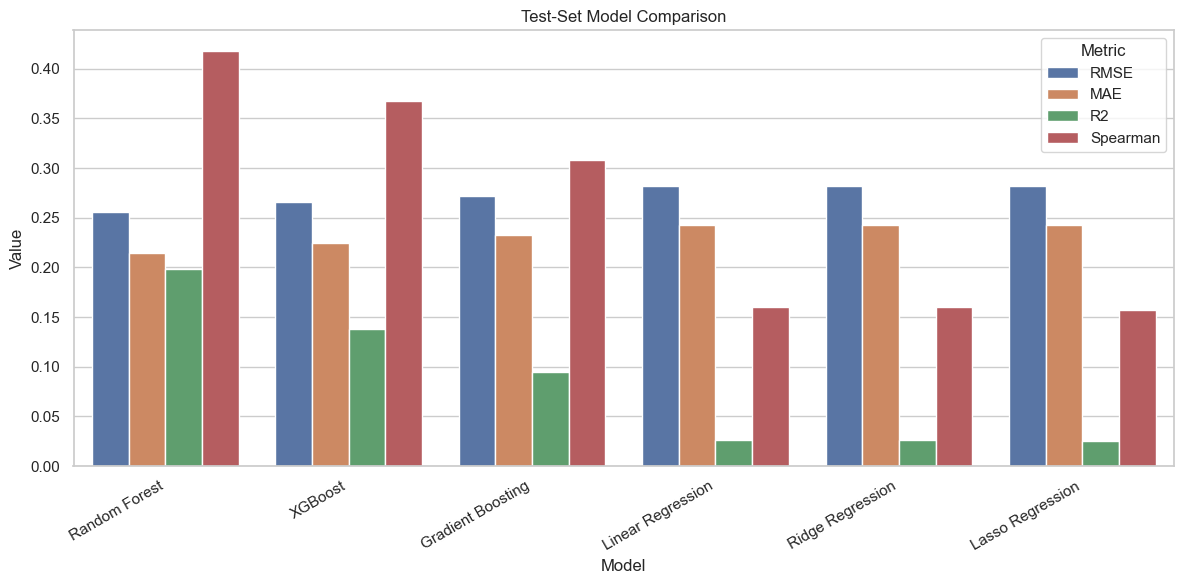

In [21]:
plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE", "R2", "Spearman"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Value", hue="Metric")
plt.title("Test-Set Model Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 11. Best Model Analysis

We use the best test-set model for deeper interpretation. In most versions of this project, this is expected to be a nonlinear ensemble, especially Random Forest.

In [22]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

print("Best model based on RMSE:", best_model_name)

Best model based on RMSE: Random Forest


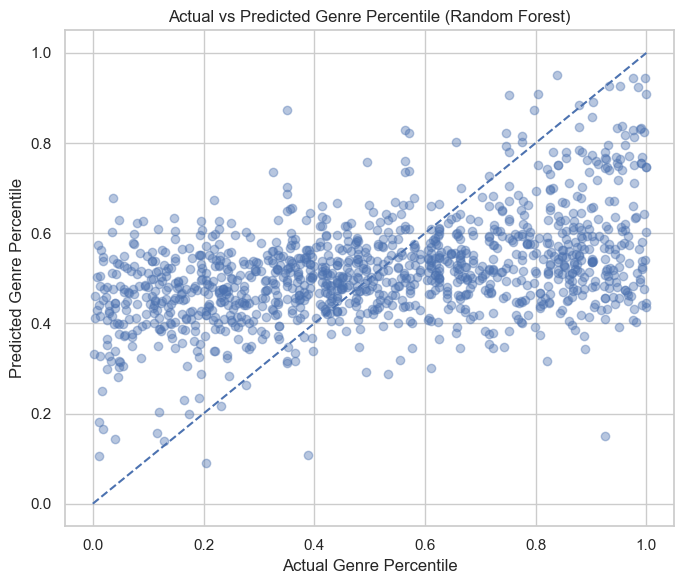

In [23]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_preds, alpha=0.4)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"Actual vs Predicted Genre Percentile ({best_model_name})")
plt.xlabel("Actual Genre Percentile")
plt.ylabel("Predicted Genre Percentile")
plt.tight_layout()
plt.show()

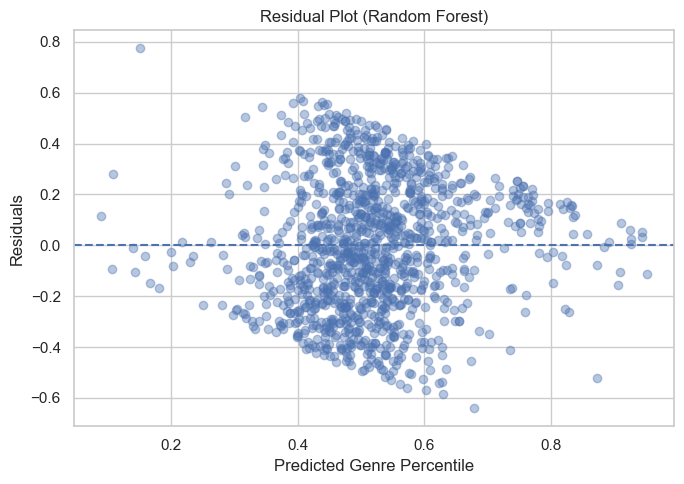

In [24]:
residuals = y_test - best_preds

plt.figure(figsize=(7, 5))
plt.scatter(best_preds, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot ({best_model_name})")
plt.xlabel("Predicted Genre Percentile")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

## 12. Linear Model Coefficients

These help with interpretation even if the linear models do not perform especially well.

In [25]:
linear_model = models["Linear Regression"].fit(X_train, y_train)
ridge_model = models["Ridge Regression"].fit(X_train, y_train)
lasso_model = models["Lasso Regression"].fit(X_train, y_train)

coef_df = pd.DataFrame({
    "Feature": features,
    "Linear_Coefficient": linear_model.named_steps["model"].coef_,
    "Ridge_Coefficient": ridge_model.named_steps["model"].coef_,
    "Lasso_Coefficient": lasso_model.named_steps["model"].coef_
}).sort_values("Ridge_Coefficient", key=np.abs, ascending=False)

coef_df

,Feature,Linear_Coefficient,Ridge_Coefficient,Lasso_Coefficient
5,instrumentalness,-0.0309,-0.0309,-0.0291
0,danceability,0.0277,0.0277,0.0267
1,energy,-0.0203,-0.0203,-0.0160
3,speechiness,-0.0162,-0.0162,-0.0146
7,valence,-0.0152,-0.0152,-0.0133
2,loudness,0.0112,0.0112,0.0073
9,duration_ms,-0.0077,-0.0077,-0.0067
8,tempo,0.0058,0.0058,0.0045
10,mode,-0.0047,-0.0047,-0.0037
11,key,0.0033,0.0033,0.0024


## 13. Feature Importance for Tree-Based Models

,Feature,Importance
2,loudness,0.1125
9,duration_ms,0.1028
1,energy,0.1011
0,danceability,0.0996
8,tempo,0.0943
4,acousticness,0.0938
3,speechiness,0.0930
7,valence,0.0914
6,liveness,0.0853
5,instrumentalness,0.0689


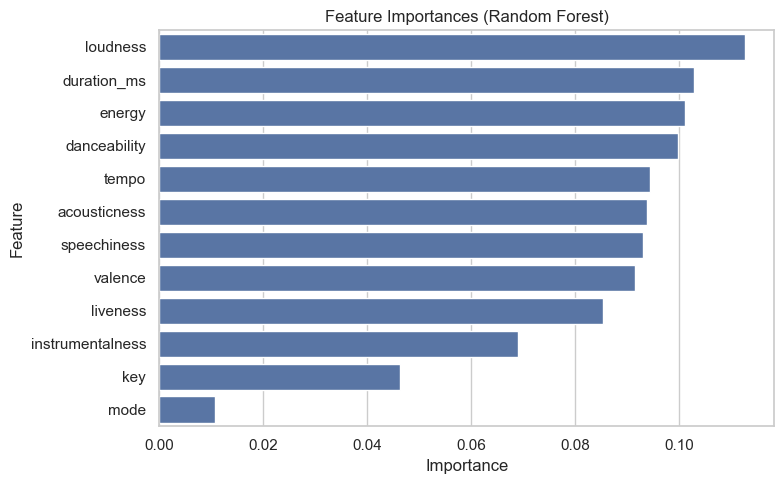

In [26]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title(f"Feature Importances ({best_model_name})")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not provide feature_importances_.")

## 14. Genre-Level Error Analysis

This section helps explain where the best model struggles the most.

In [27]:
genre_eval = pd.DataFrame({
    "playlist_genre": test_genres.values,
    "actual": y_test.values,
    "predicted": best_preds
})

genre_eval["absolute_error"] = np.abs(genre_eval["actual"] - genre_eval["predicted"])

genre_error_summary = (
    genre_eval.groupby("playlist_genre")
    .agg(
        n_tracks=("actual", "size"),
        mean_absolute_error=("absolute_error", "mean"),
        mean_actual=("actual", "mean"),
        mean_predicted=("predicted", "mean")
    )
    .sort_values(["mean_absolute_error", "n_tracks"], ascending=[False, False])
)

genre_error_summary.head(10)

,n_tracks,mean_absolute_error,mean_actual,mean_predicted
playlist_genre,,,,
disco,2,0.4283,0.7500,0.3217
mandopop,5,0.3021,0.4714,0.5848
reggae,7,0.2919,0.5476,0.5159
cantopop,8,0.2724,0.5995,0.5471
turkish,22,0.2671,0.6661,0.5004
indie,5,0.2640,0.5471,0.5054
punk,18,0.2582,0.5477,0.4873
j-pop,6,0.2565,0.5036,0.5367
rock,88,0.2474,0.5167,0.5051


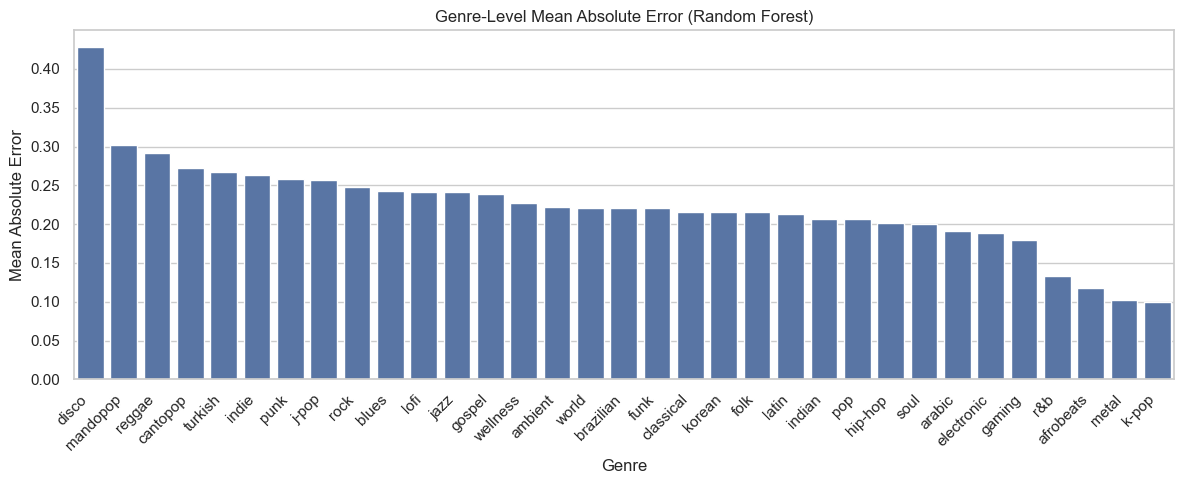

In [28]:
plt.figure(figsize=(12, 5))
genre_plot = genre_error_summary.reset_index().sort_values("mean_absolute_error", ascending=False)
sns.barplot(data=genre_plot, x="playlist_genre", y="mean_absolute_error")
plt.title(f"Genre-Level Mean Absolute Error ({best_model_name})")
plt.xlabel("Genre")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 15. Final Interpretation

### Main takeaways

- Linear models usually perform poorly, which suggests that the relationship between audio features and relative popularity is not well captured by a simple linear form. 
- Lasso typically does not add much once the linear baseline is already weak. but including it helps confirm that the sparsity alone does not solve the problem. 
- Nonlinear ensemble models generally perform better, especially on ranking-oriented metrics like Spearman correlation. 
- Even the best model usually has only modest predictive power, which supports the conclusion that audio features matter, but they are only one part of what drives popularity

### Why Performance is Limited

This project uses only intrinsic audio features. Many real-world drivers of popularity are not included, such as:

- artist reputation
- playlist placement
- label support
- social media exposure
- timing of release
- broader cultural trends

### Conclusion

This notebook supports a reasonable final conclusion: **Spotify audio features contain some signal for identifying relative outperformance within genre, but the signal is modest and unstable.*** They may still be useful in a screening context, but they are not enough on their own for reliable breakout prediction.